In [6]:
# Choosing optimal k for K-Means:
# Elbow Method + Silhouette Score

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create synthetic clustering data
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

# Compute metrics for different k values
k_values = range(2, 15)

wcss = []          # Within-Cluster Sum of Squares
sil_scores = []    # Silhouette Scores

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    # Elbow metric
    wcss.append(kmeans.inertia_)

    # Silhouette Score
    sil_scores.append(silhouette_score(X, labels))

wcss


[9416.214004352274,
 2110.4125218953295,
 564.9141808210252,
 512.3903339109634,
 460.3079031235533,
 408.9473812641575,
 360.8214343877638,
 325.37268835521905,
 291.5608624106775,
 261.1127818951174,
 233.7657418550425,
 219.5475170972828,
 203.65412799725823]

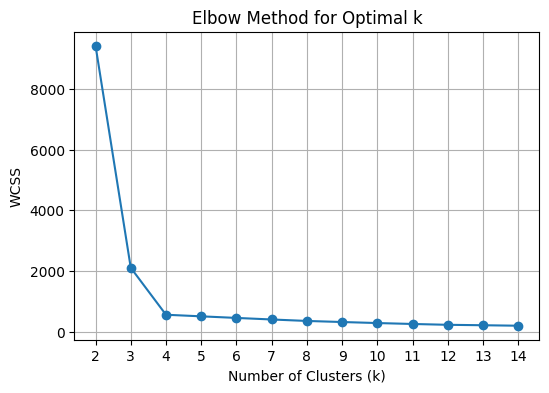

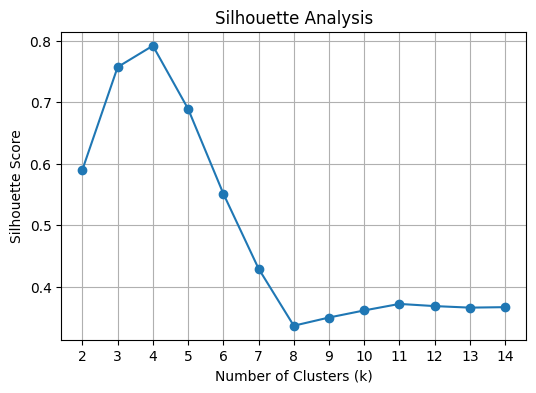

In [8]:
# Plot Elbow Method
plt.figure(figsize=(6, 4))

plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)

plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(6, 4))

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [9]:
# Print best k by Silhouette Score
best_k = k_values[np.argmax(sil_scores)]

print(f"Best k by Silhouette Score: {best_k}")
print(f"Highest Silhouette Score: {max(sil_scores):.4f}")

Best k by Silhouette Score: 4
Highest Silhouette Score: 0.7916
